## Data Preprocessing

Processes the raw data into clean, consistent time series data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from pingouin import multivariate_normality

from scipy.stats import wilcoxon, skew

### Read Data:
Read in data exported from eikon datastream.
- Period: 01.01.2000 - 01.04.2024

In [2]:
data_path = "../data/raw/"

return_data = pd.read_excel(data_path + "stock_return_data.xlsx")

In [3]:
return_data

,RIC,date,Total_Return,Price_Close,Beta,Price_To_Book_Value_Per_Share
0,POOL.OQ,2000-01-31,-6.521010e-10,5.123448,NaN,NaN
1,POOL.OQ,2000-02-29,-4.337349e+00,4.901226,NaN,NaN
2,POOL.OQ,2000-03-31,2.342569e+01,6.049372,NaN,NaN
3,POOL.OQ,2000-04-28,2.020408e+01,7.271592,NaN,NaN
4,POOL.OQ,2000-05-31,-7.979626e+00,6.691346,NaN,NaN
...,...,...,...,...,...,...
142726,AVY.N,2022-07-31,NaN,NaN,0.976475,NaN
142727,AVY.N,2022-12-31,NaN,NaN,0.994097,NaN
142728,AVY.N,2023-04-30,NaN,NaN,0.963044,NaN
142729,AVY.N,2023-09-30,NaN,NaN,0.958817,NaN


In [36]:
# Select only returns

return_df = return_data[['RIC', 'date', 'Total_Return']]

display(return_df)

,RIC,date,Total_Return
0,POOL.OQ,2000-01-31,-6.521010e-10
1,POOL.OQ,2000-02-29,-4.337349e+00
2,POOL.OQ,2000-03-31,2.342569e+01
3,POOL.OQ,2000-04-28,2.020408e+01
4,POOL.OQ,2000-05-31,-7.979626e+00
...,...,...,...
142726,AVY.N,2022-07-31,NaN
142727,AVY.N,2022-12-31,NaN
142728,AVY.N,2023-04-30,NaN
142729,AVY.N,2023-09-30,NaN


## Data Preparation

In [37]:
# Problem: Duplikate in der RIC bei denen ein Wert Daten hat und ein anderer nicht.

def keep_best_of_duplicate_rows(data):
    '''
    Checks for duplicates in the RIC and date and then only keeps the row with the least null values.
    '''
    # Check for duplicates in the 'RIC' column
    duplicate_mask = data.duplicated(subset=['RIC', 'date'], keep=False)
    
    # Create a DataFrame with only duplicated rows
    duplicated_rows = data[duplicate_mask]
    
    duplicated_rows['null_count'] = duplicated_rows.isnull().sum(axis=1)
    
    duplicated_rows_sorted = duplicated_rows.sort_values(by='null_count')
    
    # Keep the rows with the minimal 'null_count' for each unique 'RIC'
    dropped_df = duplicated_rows_sorted.drop_duplicates(subset=['RIC', 'date'], keep='first')
    
    # Get the indexes of the dropped rows to also drop them in data.
    dropped_indexes = duplicated_rows_sorted.index.difference(dropped_df.index)

    # Drop thes indexes in the original data and return.
    cleaned_data = data.drop(dropped_indexes, axis=0)

    return cleaned_data

return_df = keep_best_of_duplicate_rows(return_df)

display(return_df)

,RIC,date,Total_Return
0,POOL.OQ,2000-01-31,-6.521010e-10
1,POOL.OQ,2000-02-29,-4.337349e+00
2,POOL.OQ,2000-03-31,2.342569e+01
3,POOL.OQ,2000-04-28,2.020408e+01
4,POOL.OQ,2000-05-31,-7.979626e+00
...,...,...,...
142726,AVY.N,2022-07-31,NaN
142727,AVY.N,2022-12-31,NaN
142728,AVY.N,2023-04-30,NaN
142729,AVY.N,2023-09-30,NaN


### 1. Investigate missings

C:\Users\maxiw\AppData\Local\Temp\ipykernel_7336\3089449036.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  missings_df['Missing_Count'] = missings_df['Missing_Count'].fillna(0, inplace=True)


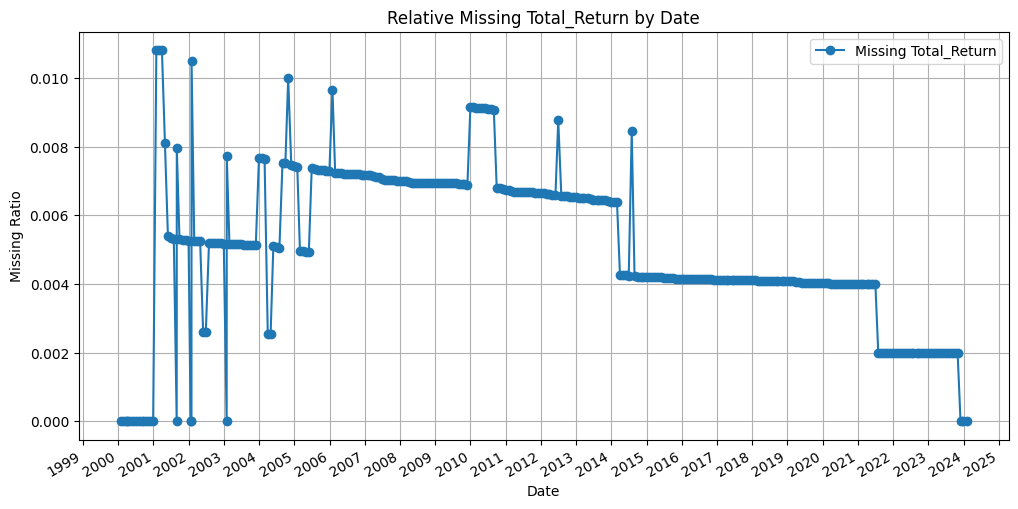

In [38]:
return_df['date'] = pd.to_datetime(return_df['date'])

# Count total and missing values per date
total_counts = return_df.groupby('date')['RIC'].count().reset_index(name='Total_Count')
missing_counts = return_df[return_df['Total_Return'].isnull()].groupby('date')['RIC'].count().reset_index(name='Missing_Count')

# Merge total and missing counts
missings_df = pd.merge(total_counts, missing_counts, on='date', how='left')
missings_df['Missing_Count'] = missings_df['Missing_Count'].fillna(0, inplace=True)

# Calculate share of missing values
missings_df['Missing_Ratio'] = missings_df['Missing_Count'] / missings_df['Total_Count']

# Filter out dates with 100% missing data
valid_dates = missings_df[missings_df['Missing_Ratio'] < 1.0]

plt.figure(figsize=(12, 6))
plt.plot(valid_dates['date'], valid_dates['Missing_Ratio'], label='Missing Total_Return', marker='o')
plt.title('Relative Missing Total_Return by Date')
plt.xlabel('Date')
plt.ylabel('Missing Ratio')
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.show()

In [39]:
# Exclude invalid dates with 100% missings
valid_dates_list = valid_dates['date']
return_df1 = return_df[return_df['date'].isin(valid_dates_list)].copy()

# Identify the RICs which are never missing

# Count number of missing Total_Return values per RIC
missing_per_ric = return_df1.groupby('RIC')['Total_Return'].apply(lambda x: x.isnull().sum())

rics_no_missing = missing_per_ric[missing_per_ric == 0].index.tolist()

print(f"Number of RICs which have no missing Total_Returns: {len(rics_no_missing)}")

# Select RICs without missings

return_df2 = return_df1[return_df1['RIC'].isin(rics_no_missing)].copy()

display(return_df2)

Number of RICs which have no missing Total_Returns: 486


,RIC,date,Total_Return
0,POOL.OQ,2000-01-31,-6.521010e-10
1,POOL.OQ,2000-02-29,-4.337349e+00
2,POOL.OQ,2000-03-31,2.342569e+01
3,POOL.OQ,2000-04-28,2.020408e+01
4,POOL.OQ,2000-05-31,-7.979626e+00
...,...,...,...
142698,AVY.N,2023-09-29,-2.604373e+00
142699,AVY.N,2023-10-31,-4.707943e+00
142700,AVY.N,2023-11-30,1.173666e+01
142701,AVY.N,2023-12-29,4.374047e+00


In [40]:
# Transform into percentage Return by dividing by 100 (Total Return is in absolute Percentages)
print(f"Anzahl Total_Return < -100%: {len(return_df2[return_df2['Total_Return'] < -100])}")

return_df2['return'] = (return_df2['Total_Return'] / 100)
return_df2 = return_df2.drop(columns=['Total_Return'])

display(return_df2)

Anzahl Total_Return < -100%: 0


,RIC,date,return
0,POOL.OQ,2000-01-31,-6.521010e-12
1,POOL.OQ,2000-02-29,-4.337349e-02
2,POOL.OQ,2000-03-31,2.342569e-01
3,POOL.OQ,2000-04-28,2.020408e-01
4,POOL.OQ,2000-05-31,-7.979626e-02
...,...,...,...
142698,AVY.N,2023-09-29,-2.604373e-02
142699,AVY.N,2023-10-31,-4.707943e-02
142700,AVY.N,2023-11-30,1.173666e-01
142701,AVY.N,2023-12-29,4.374047e-02


### 2. Check for stationarity

In [41]:
stationarity_results = []

min_obs = 30

# Apply ADF test on returns of every RIC
for ric, group in return_df2.groupby('RIC'):
    series = group.sort_values('date')['return'].dropna()
    
    if len(series) < min_obs:
        print(f"Skipping RIC {ric} due to insufficient observations ({len(series)}).")
        continue

    result = adfuller(series, autolag='AIC')
    p_value = result[1]
    test_stat = result[0]
    is_stationary = p_value < 0.05

    stationarity_results.append({
        'RIC': ric,
        'ADF_statistic': test_stat,
        'p_value': p_value,
        'is_stationary': is_stationary
    })

stationarity_df = pd.DataFrame(stationarity_results)

stationary_rics = stationarity_df[stationarity_df['is_stationary']]['RIC'].tolist()

# Display summary
print(f"Total RICs tested: {len(stationarity_df)}")
print(f"Stationary RICs at 5% level: {len(stationary_rics)}")

Skipping RIC CEG.OQ due to insufficient observations (25).
Skipping RIC GEHC.OQ due to insufficient observations (14).
Skipping RIC KVUE.N due to insufficient observations (9).
Skipping RIC VLTO.N due to insufficient observations (5).
Total RICs tested: 482
Stationary RICs at 5% level: 478


In [42]:
display(stationarity_df[stationarity_df['is_stationary'] == False])

,RIC,ADF_statistic,p_value,is_stationary
118,CTVA.N,-2.183354,0.212342,False
315,MTCH.OQ,-2.303067,0.170981,False
345,PAYC.N,-1.808653,0.376174,False
436,UBER.N,-1.499424,0.533796,False


In [43]:
# Exclude non stationary RICs
stationary_return_df = return_df2[return_df2['RIC'].isin(stationary_rics)]
display(stationary_return_df)

,RIC,date,return
0,POOL.OQ,2000-01-31,-6.521010e-12
1,POOL.OQ,2000-02-29,-4.337349e-02
2,POOL.OQ,2000-03-31,2.342569e-01
3,POOL.OQ,2000-04-28,2.020408e-01
4,POOL.OQ,2000-05-31,-7.979626e-02
...,...,...,...
142698,AVY.N,2023-09-29,-2.604373e-02
142699,AVY.N,2023-10-31,-4.707943e-02
142700,AVY.N,2023-11-30,1.173666e-01
142701,AVY.N,2023-12-29,4.374047e-02


### 3. Include only permanent constituents

In [44]:
stationary_return_df['date'].iloc[0]

Timestamp('2000-01-31 00:00:00')

In [45]:
# Only take constituents of the SP500 which permanently were in it for the whole time horizon

ric_periods = stationary_return_df.groupby('RIC')['date'].agg(['min', 'max']).reset_index()
ric_permanent = ric_periods[ric_periods['min'] == ric_periods['min'].min()]['RIC'].tolist()
print(f"Number of permanent constituents: {len(ric_permanent)}")
display(ric_periods)

Number of permanent constituents: 352


,RIC,min,max
0,A.N,2000-01-31,2024-01-31
1,AAL.OQ,2013-12-31,2024-01-31
2,AAPL.OQ,2000-01-31,2024-01-31
3,ABBV.N,2012-12-31,2024-01-31
4,ABNB.OQ,2020-12-31,2024-01-31
...,...,...,...
473,YUM.N,2000-01-31,2024-01-31
474,ZBH.N,2001-07-31,2024-01-31
475,ZBRA.OQ,2000-01-31,2024-01-31
476,ZION.OQ,2000-01-31,2024-01-31


In [46]:
# Filter on permanent constituents.
# Done because longer time horizons are required for efficient bootstrapping.

stationary_return_df1 = stationary_return_df[stationary_return_df['RIC'].isin(ric_permanent)]
display(stationary_return_df1)

,RIC,date,return
0,POOL.OQ,2000-01-31,-6.521010e-12
1,POOL.OQ,2000-02-29,-4.337349e-02
2,POOL.OQ,2000-03-31,2.342569e-01
3,POOL.OQ,2000-04-28,2.020408e-01
4,POOL.OQ,2000-05-31,-7.979626e-02
...,...,...,...
142698,AVY.N,2023-09-29,-2.604373e-02
142699,AVY.N,2023-10-31,-4.707943e-02
142700,AVY.N,2023-11-30,1.173666e-01
142701,AVY.N,2023-12-29,4.374047e-02


In [47]:
# Check if all RICs have the same number of observations (should be the case since they are all permanent constituents)
stationary_return_df1.groupby('RIC').count()['return'].describe()

count    352.0
mean     289.0
std        0.0
min      289.0
25%      289.0
50%      289.0
75%      289.0
max      289.0
Name: return, dtype: float64

In [48]:
# Test for multivariate normal distribution:
# Henze-Zirkler multivariate normality test

return_mat = (
    stationary_return_df1
    .pivot(index="date", columns="RIC", values="return")
    .dropna(axis=0)
)

result = multivariate_normality(return_mat, alpha=0.05)
hz_stat = result[0]
p_value = result[1]
print(f"Henze–Zirkler stat: {hz_stat:.4g},  p-value: {p_value:.4g}")
print("Reject multivariate normality at 5%:", p_value < 0.05)
print(result)

Henze–Zirkler stat: 1156,  p-value: 0
Reject multivariate normality at 5%: True
HZResults(hz=1156, pval=np.float64(0.0), normal=False)


In [49]:
# Symmetry check using skewness (not quite what we need for the assumption in SPO+ paper)


skewness_values = return_mat.apply(skew)

print("\nSkewness summary:")
print(skewness_values.describe())

# Wilcoxon signed-rank test
# H0: Median return = 0
# Per RIC

wilcoxon_results = []

for ric in return_mat.columns:

    series = return_mat[ric].dropna()

    # Wilcoxon signed-rank test against median = 0
    stat, pval = wilcoxon(series)

    wilcoxon_results.append({
        "RIC": ric,
        "wilcoxon_stat": stat,
        "p_value": pval,
        "reject_H0_5pct": pval < 0.05
    })

wilcoxon_df = pd.DataFrame(wilcoxon_results)

print("\nWilcoxon signed-rank test results:")
print(wilcoxon_df.head())

# Optional summary
print("\nFraction rejecting H0 at 5%:")
print(wilcoxon_df["reject_H0_5pct"].mean())


Skewness summary:
count    352.000000
mean       0.238251
std        1.009007
min       -1.918501
25%       -0.198717
50%        0.044489
75%        0.338328
max        8.575010
dtype: float64

Wilcoxon signed-rank test results:
       RIC  wilcoxon_stat   p_value  reject_H0_5pct
0      A.N        18956.0  0.160299           False
1  AAPL.OQ        14561.0  0.000007            True
2    ABT.N        16163.0  0.000756            True
3  ACGL.OQ        14121.0  0.000002            True
4  ADBE.OQ        16281.0  0.001019            True

Fraction rejecting H0 at 5%:
0.7926136363636364


In [ ]:
# Save preprocessed return data

stationary_return_df1.to_csv("../data/processed/stationary_return_data.csv", index=False)

## Create a subset for developement

In [3]:
return_data = pd.read_csv("../data/processed/stationary_return_data.csv")

In [4]:
# Pivot return data
return_matrix = return_data.pivot(index='date', columns='RIC', values='return')
display(return_matrix)

RIC,A.N,AAPL.OQ,ABT.N,ACGL.OQ,ADBE.OQ,ADI.OQ,ADM.N,ADP.OQ,ADSK.OQ,AEE.N,...,WMB.N,WMT.N,WST.N,WY.N,XEL.OQ,XOM.N,XRAY.OQ,YUM.N,ZBRA.OQ,ZION.OQ
date,,,,,,,,,,,,,,,,,,,,,
2000-01-31,-0.143897,0.009119,-0.097065,0.158416,-0.181227,0.005376,-0.035897,-0.119490,-0.092685,-5.725191e-03,...,0.267894,-0.207957,0.005608,-0.195522,-0.012821,0.036462,0.047619,-0.258900,0.011752,0.003960
2000-02-29,0.566572,0.104819,0.003831,0.042735,0.852440,0.679144,-0.139973,-0.081686,0.462168,-7.869482e-02,...,0.079032,-0.110731,-0.048485,-0.105664,-0.087662,-0.092836,0.035354,-0.069869,0.124604,-0.102537
2000-03-31,0.003014,0.184842,0.074427,0.073770,0.091363,0.026274,0.031056,0.109845,0.018182,5.474215e-02,...,0.054239,0.141254,-0.140127,0.110840,0.131673,0.033195,0.109834,0.166667,-0.248826,-0.215548
2000-04-28,-0.147837,-0.086516,0.097600,-0.060115,0.086468,-0.046548,-0.042169,0.115285,-0.155477,1.858586e-01,...,-0.150782,-0.002252,-0.027729,-0.062500,0.116715,-0.001606,0.024229,0.098592,0.140000,-0.003003
2000-05-31,-0.169252,-0.322922,0.058537,-0.025381,-0.069251,0.002441,0.207154,0.020906,-0.030945,-7.407630e-12,...,0.113903,0.040632,-0.038363,-0.064345,0.014327,0.078095,0.055914,-0.141026,-0.157895,0.131392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-29,-0.076402,-0.088678,-0.058795,0.037080,-0.088390,-0.032262,-0.048928,-0.050382,-0.067721,-4.845823e-02,...,-0.011417,-0.016481,-0.077882,-0.063817,0.010451,0.057469,-0.075219,-0.034318,-0.139922,-0.017183
2023-10-31,-0.073692,-0.002570,-0.018228,0.087442,0.043460,-0.101434,-0.051047,-0.092942,-0.044850,1.175999e-02,...,0.021075,0.021760,-0.151702,-0.064253,0.035827,-0.099762,-0.109778,-0.032656,-0.114573,-0.115792
2023-11-30,0.236335,0.113747,0.103014,-0.034495,0.148386,0.165576,0.036457,0.053616,0.105247,2.483159e-02,...,0.069477,-0.047243,0.102681,0.099338,0.026489,-0.020540,0.044064,0.043727,0.131548,0.168970


In [5]:
# Sample down the return data to 10 least uncorrelated assets:

# fill remaining missing values
return_matrix = return_matrix.fillna(0)

# absolute correlation matrix
corr = return_matrix.corr().abs()

# average correlation per asset
avg_corr = corr.mean()

# first asset = least correlated overall
selected = [avg_corr.idxmin()]

n_assets = 10

while len(selected) < n_assets:

    remaining = list(set(corr.columns) - set(selected))

    scores = {}

    for asset in remaining:

        # mean correlation with selected assets
        scores[asset] = corr.loc[asset, selected].mean()

    next_asset = min(scores, key=scores.get)

    selected.append(next_asset)

print("Selected RICs:")
print(selected)

# final subset
return_subset = return_matrix[selected]

print(return_subset.shape)

Selected RICs:
['NEM.N', 'CVS.N', 'FFIV.OQ', 'BRO.N', 'REGN.OQ', 'PCG.N', 'CTRA.N', 'HSY.N', 'TYL.N', 'LLY.N']
(289, 10)


In [6]:
return_subset_long = return_data[return_data['RIC'].isin(selected)]

In [7]:
return_subset_long

,RIC,date,return
3468,CTRA.N,2000-01-31,-0.081712
3469,CTRA.N,2000-02-29,0.074857
3470,CTRA.N,2000-03-31,0.142292
3471,CTRA.N,2000-04-28,0.027682
3472,CTRA.N,2000-05-31,0.345877
...,...,...,...
68488,TYL.N,2023-09-29,-0.030846
68489,TYL.N,2023-10-31,-0.034288
68490,TYL.N,2023-11-30,0.096380
68491,TYL.N,2023-12-29,0.022698


In [8]:
# Save preprocessed return data subset

return_subset_long.to_csv("../data/processed/stationary_return_data_subset.csv", index=False)